In [1]:
# ── ROC CURVE — My First Real ML Code ───────────────

# Step 1: Import everything
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Step 2: Load data
data = load_breast_cancer()
X = data.data
y = data.target

print("Dataset shape:", X.shape)
print("Classes:", data.target_names)

Dataset shape: (569, 30)
Classes: ['malignant' 'benign']


In [3]:
# Step 3: Split into train and test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape: ", y_test.shape)


X_train shape: (455, 30)
X_test shape:  (114, 30)
y_train shape: (455,)
y_test shape:  (114,)


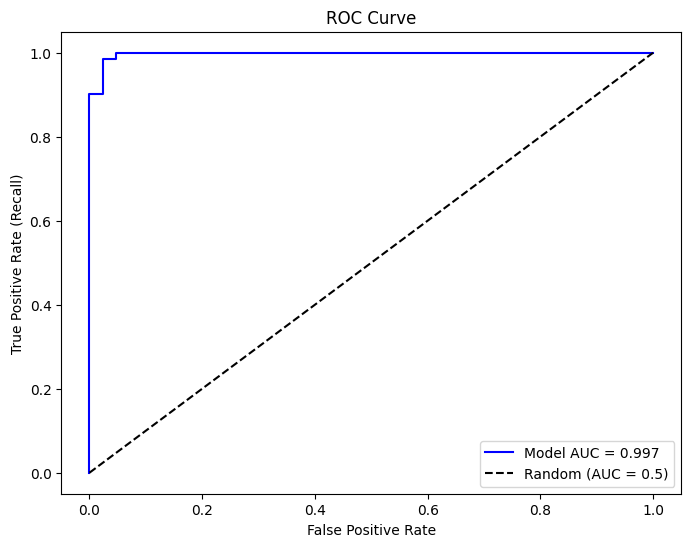

AUC Score: 0.997


In [4]:
# ── STEP 4: Scale features ───────────────────────────
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# ── STEP 5: Train the model ──────────────────────────
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_s, y_train)

# ── STEP 6: Get probability scores ───────────────────
# This is where y_pred_proba comes from
# predict_proba gives probability for EACH class
# [:,1] means "give me probability of class 1 (benign)"
y_pred_proba = model.predict_proba(X_test_s)[:,1]

# ── STEP 7: Plot the ROC curve ───────────────────────
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Model AUC = {auc_score:.3f}', color='blue')
plt.plot([0,1], [0,1], 'k--', label='Random (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve')
plt.legend()
plt.show()

print(f'AUC Score: {auc_score:.3f}')

In [9]:
#What y_pred_proba Actually Is
# predict_proba returns TWO columns:
# Column 0 = probability of being class 0 (malignant)
# Column 1 = probability of being class 1 (benign)

# Example output for 3 patients:
# [[0.03, 0.97],   ← 97% chance benign
#  [0.88, 0.12],   ← 88% chance malignant
#  [0.45, 0.55]]   ← 55% chance benign (borderline)

# We take [:,1] — the second column only
# because ROC curve only needs the POSITIVE class probability
